In [ ]:
!kill-9 -1

In [1]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      //const capture = document.createElement('button');
      //capture.textContent = 'Capture';
      //div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      //document.body.appendChild(div);
      //div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      //await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      //stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

<IPython.core.display.Javascript object>

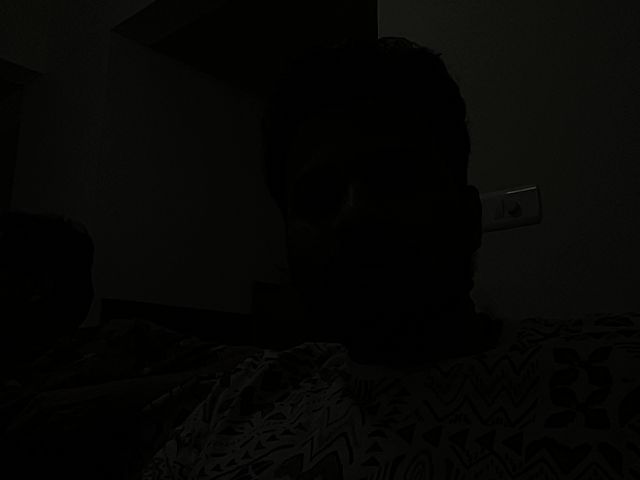

In [2]:
from IPython.display import Image
try:
  filename = take_photo()
  #print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
import os
os.chdir('/content/gdrive/My Drive/YOLO-series-master')

In [ ]:
import cv2
from darkflow.net.build import TFNet
import numpy as np
import time
from IPython.display import Image
from IPython.display import clear_output
import cv2
import PIL
from IPython.display import display
options = {
      'model': '/content/gdrive/My Drive/YOLO-series-master/cfg/tiny-yolo-voc.cfg',
      'load': '/content/gdrive/My Drive/YOLO-series-master/bin/tiny-yolo-voc.weights',
      'threshold': 0.2,
      'gpu': 1.0
  }
tfnet = TFNet(options)
colors = [tuple(255 * np.random.rand(3)) for _ in range(10)]


def cv2_imshow(a):
  """A replacement for cv2.imshow() for use in Jupyter notebooks."""
  a = a.clip(0, 255).astype('uint8')
  # cv2 stores colors as BGR; convert to RGB
  if a.ndim == 3:
    if a.shape[2] == 4:
      a = cv2.cvtColor(a, cv2.COLOR_BGRA2RGBA)
    else:
      a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
  display(PIL.Image.fromarray(a))
while(1):
  filename = take_photo()
  #capture = cv2.VideoCapture(0)
  #capture=Image(filename)
  #capture.set(cv2.CAP_PROP_FRAME_WIDTH, 512)
  #capture.set(cv2.CAP_PROP_FRAME_HEIGHT, 512)
  stime = time.time()
  frame = cv2.imread(filename)
  results = tfnet.return_predict(frame)
  for color, result in zip(colors, results):
      tl = (result['topleft']['x'], result['topleft']['y'])
      br = (result['bottomright']['x'], result['bottomright']['y'])
      label = result['label']
      confidence = result['confidence']
      text = '{}: {:.0f}%'.format(label, confidence * 100)
      frame = cv2.rectangle(frame, tl, br, color, 5)
      frame = cv2.putText(
          frame, text, tl, cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 0), 2)
  clear_output()
  cv2_imshow(frame)

  #cv2.imwrite("face.jpg", frame)
  #display(Image('face.jpg'))

  #print('FPS {:.1f}'.format(1 / (time.time() - stime)))
  #capture.release()
  #cv2.destroyAllWindows()


In [ ]:
import cv2
import numpy as np
import PIL
from IPython.display import display

def cv2_imshow(a):
  """A replacement for cv2.imshow() for use in Jupyter notebooks."""
  a = a.clip(0, 255).astype('uint8')
  # cv2 stores colors as BGR; convert to RGB
  if a.ndim == 3:
    if a.shape[2] == 4:
      a = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
    else:
      a = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  display(PIL.Image.fromarray(a))

In [ ]:
import cv2
from darkflow.net.build import TFNet
import numpy as np
import time

def cv2_imshow(a):
  """A replacement for cv2.imshow() for use in Jupyter notebooks."""
  a = a.clip(0, 255).astype('uint8')
  # cv2 stores colors as BGR; convert to RGB
  if a.ndim == 3:
    if a.shape[2] == 4:
      a = cv2.cvtColor(a, cv2.COLOR_BGRA2RGBA)
    else:
      a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
  display(PIL.Image.fromarray(a))
options = {
    'model': 'cfg/tiny-yolo-voc.cfg',
    'load': 'bin/tiny-yolo-voc.weights',
    'threshold': 0.2,
    'gpu': 0.0
}

tfnet = TFNet(options)
colors = [tuple(255 * np.random.rand(3)) for _ in range(10)]

capture = cv2.VideoCapture(0)
capture.set(cv2.CAP_PROP_FRAME_WIDTH, 512)
capture.set(cv2.CAP_PROP_FRAME_HEIGHT, 512)

while True:
    stime = time.time()
    ret, frame = capture.read()
    if ret:
        results = tfnet.return_predict(frame)
        for color, result in zip(colors, results):
            tl = (result['topleft']['x'], result['topleft']['y'])
            br = (result['bottomright']['x'], result['bottomright']['y'])
            label = result['label']
            confidence = result['confidence']
            text = '{}: {:.0f}%'.format(label, confidence * 100)
            frame = cv2.rectangle(frame, tl, br, color, 5)
            frame = cv2.putText(
                frame, text, tl, cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 0), 2)
        cv2_imshow(frame)
       # print('FPS {:.1f}'.format(1 / (time.time() - stime)))
   # if cv2.waitKey(1) & 0xFF == ord('q'):
        #break

#capture.release()
#cv2.destroyAllWindows()


Parsing ./cfg/tiny-yolo-voc.cfg
Parsing cfg/tiny-yolo-voc.cfg
Loading bin/tiny-yolo-voc.weights ...
Successfully identified 63471556 bytes
Finished in 0.025787353515625s
Model has a VOC model name, loading VOC labels.

Building net ...
Source | Train? | Layer description                | Output size
-------+--------+----------------------------------+---------------
       |        | input                            | (?, 416, 416, 3)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 416, 416, 16)
 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 208, 208, 16)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 208, 208, 32)
 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 104, 104, 32)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 104, 104, 64)
 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 52, 52, 64)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 52, 52, 128)
 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 26, 26, 12

Exception ignored in: <bound method ScopedTFGraph.__del__ of <tensorflow.python.framework.c_api_util.ScopedTFGraph object at 0x7fc7bad36198>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.6/dist-packages/tensorflow/python/framework/c_api_util.py", line 48, in __del__
    def __del__(self):
KeyboardInterrupt: 


KeyboardInterrupt: ignored